# 🏠 Semana 03: Regresión Lineal y Regularización
## Dataset: California Housing

**Objetivo:** Predecir el precio medio de una vivienda en California basándose en características del distrito.

**Modelos a competir:**
- Linear Regression (baseline)
- Ridge Regression (regularización L2)
- Lasso Regression (regularización L1)
- ElasticNet (combinación L1 + L2)

**Métricas de evaluación:** RMSE, MAE, R²

**Contexto de negocio:** Una inmobiliaria quiere estimar el valor de propiedades en diferentes zonas para fijar precios competitivos.

---

### ¿Qué es?
Dataset que contiene información sobre **20,640 bloques de viviendas** en California, basado en el censo de 1990. Características por distrito:
- Ingreso medio
- Edad media de las casas
- Número promedio de habitaciones
- Número promedio de dormitorios
- Población del bloque
- Ocupación promedio
- Latitud y longitud

### ¿Qué problema resuelve?
Predecir el **precio medio de una vivienda** en un distrito (valor continuo en cientos de miles de dólares).

### El Reto
Construir un modelo de **regresión** que capture relaciones no lineales (ej. el precio no crece linealmente con el ingreso, tiene saturación).

### Contexto de negocio
Una inmobiliaria quiere estimar el valor de propiedades en diferentes zonas para fijar precios competitivos.

## 1. Configuración Inicial

Importamos las librerías necesarias y configuramos la semilla para reproducibilidad.

In [1]:
# ======================================================
# SEMANA 03: CALIFORNIA HOUSING - REGRESIÓN LINEAL
# ======================================================

# Instalar librerías necesarias (solo si no están instaladas)
!pip install scikit-learn pandas numpy matplotlib seaborn -q

# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Semilla para reproducibilidad
np.random.seed(42)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2. Carga y Exploración de Datos

Cargamos el dataset California Housing directamente desde scikit-learn (online, sin descarga manual).

In [2]:
# Cargar dataset California Housing
print("="*60)
print("📊 CARGANDO DATASET CALIFORNIA HOUSING")
print("="*60)

housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

print(f"\n✅ Dataset cargado exitosamente")
print(f"📊 Shape de X: {X.shape[0]:,} muestras × {X.shape[1]} características")
print(f"🎯 Shape de y: {y.shape[0]:,} valores")
print(f"📋 Características: {list(X.columns)}")
print(f"💡 Target: Precio medio de vivienda (en cientos de miles de dólares)")

# Mostrar primeras filas
print("\n📋 Primeras 5 filas del dataset:")
display(X.head())

# Estadísticas descriptivas
print("\n📊 Estadísticas descriptivas:")
display(X.describe())

📊 CARGANDO DATASET CALIFORNIA HOUSING

✅ Dataset cargado exitosamente
📊 Shape de X: 20,640 muestras × 8 características
🎯 Shape de y: 20,640 valores
📋 Características: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
💡 Target: Precio medio de vivienda (en cientos de miles de dólares)

📋 Primeras 5 filas del dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25



📊 Estadísticas descriptivas:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


📈 ANÁLISIS EXPLORATORIO


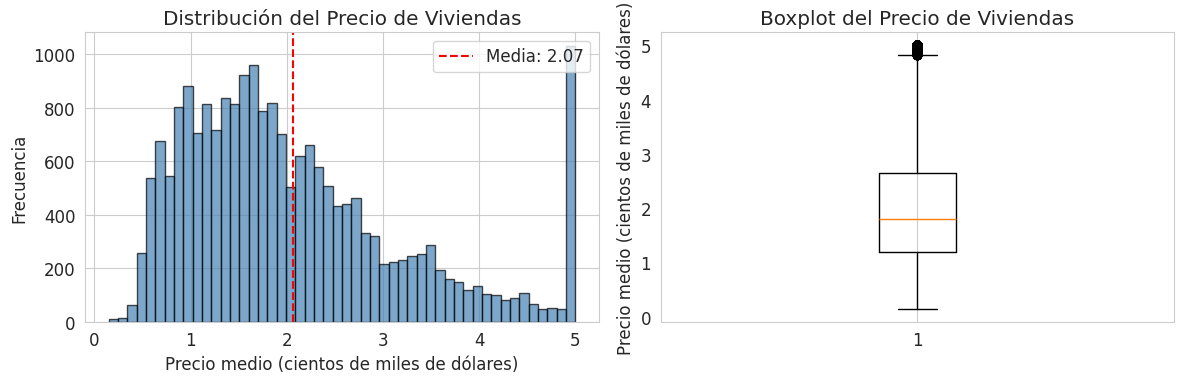

📊 Estadísticas del target:
   • Media: 2.0686
   • Mediana: 1.7970
   • Desviación estándar: 1.1540
   • Mínimo: 0.1500
   • Máximo: 5.0000


In [3]:
# Análisis exploratorio básico
print("="*60)
print("📈 ANÁLISIS EXPLORATORIO")
print("="*60)

# Distribución del target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma del target
axes[0].hist(y, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Precio medio (cientos de miles de dólares)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución del Precio de Viviendas')
axes[0].axvline(y.mean(), color='red', linestyle='--', label=f'Media: {y.mean():.2f}')
axes[0].legend()

# Boxplot del target
axes[1].boxplot(y, vert=True)
axes[1].set_ylabel('Precio medio (cientos de miles de dólares)')
axes[1].set_title('Boxplot del Precio de Viviendas')
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

print(f"📊 Estadísticas del target:")
print(f"   • Media: {y.mean():.4f}")
print(f"   • Mediana: {y.median():.4f}")
print(f"   • Desviación estándar: {y.std():.4f}")
print(f"   • Mínimo: {y.min():.4f}")
print(f"   • Máximo: {y.max():.4f}")


📊 MATRIZ DE CORRELACIÓN


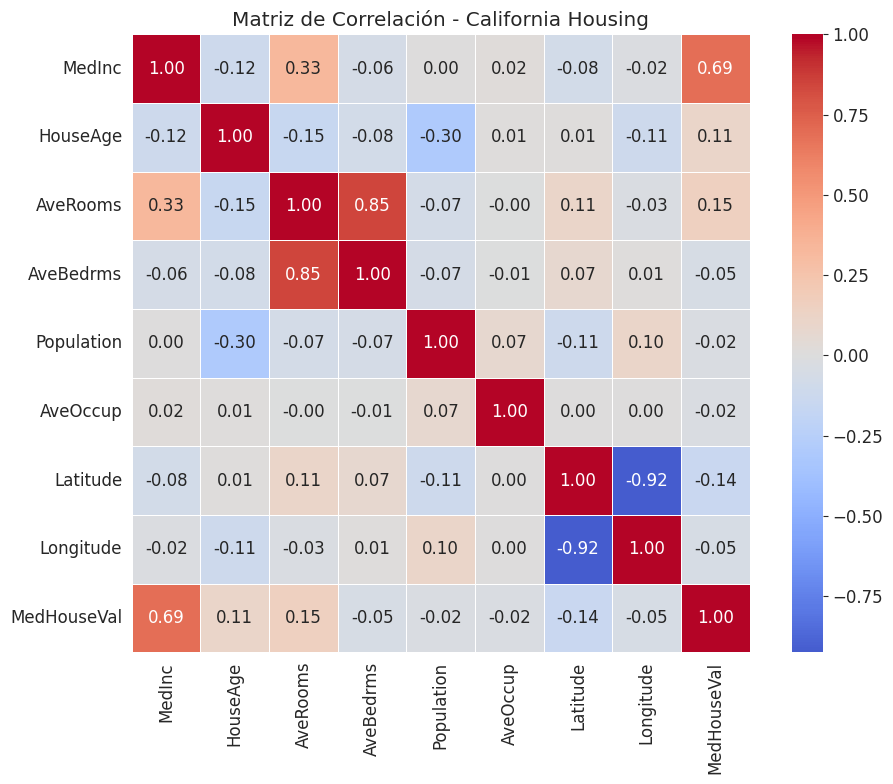


📈 Correlación de cada característica con el precio:
   • MedInc: 0.6881
   • AveRooms: 0.1519
   • HouseAge: 0.1056
   • AveOccup: -0.0237
   • Population: -0.0246
   • Longitude: -0.0460
   • AveBedrms: -0.0467
   • Latitude: -0.1442


In [4]:
# Matriz de correlación
print("\n" + "="*60)
print("📊 MATRIZ DE CORRELACIÓN")
print("="*60)

# Añadir target al DataFrame para correlación
df_full = X.copy()
df_full['MedHouseVal'] = y

# Calcular correlaciones
corr_matrix = df_full.corr()

# Visualizar matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Matriz de Correlación - California Housing')
plt.tight_layout()
plt.show()

# Mostrar correlaciones con el target
corr_target = corr_matrix['MedHouseVal'].sort_values(ascending=False)
print("\n📈 Correlación de cada característica con el precio:")
for feature, corr in corr_target.items():
    if feature != 'MedHouseVal':
        print(f"   • {feature}: {corr:.4f}")

## 3. Preprocesamiento

Dividimos los datos en entrenamiento (80%) y prueba (20%), y escalamos las características para los modelos regularizados.

In [5]:
# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"📊 División de datos:")
print(f"   • Entrenamiento: {X_train.shape[0]:,} muestras")
print(f"   • Prueba: {X_test.shape[0]:,} muestras")

# Escalar características (necesario para Ridge, Lasso y ElasticNet)
# La regresión lineal no requiere escalado, pero lo aplicamos por consistencia
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Escalado completado (media=0, std=1)")
print(f"   • Media de características (entrenamiento): {X_train_scaled.mean(axis=0).round(2)}")
print(f"   • Desviación estándar (entrenamiento): {X_train_scaled.std(axis=0).round(2)}")

📊 División de datos:
   • Entrenamiento: 16,512 muestras
   • Prueba: 4,128 muestras

✅ Escalado completado (media=0, std=1)
   • Media de características (entrenamiento): [-0. -0. -0. -0. -0.  0.  0.  0.]
   • Desviación estándar (entrenamiento): [1. 1. 1. 1. 1. 1. 1. 1.]


## 4. Entrenamiento y Comparación de Modelos

Entrenamos los 4 modelos de regresión y comparamos su rendimiento.

In [6]:
# Definir modelos
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (α=1.0)': Ridge(alpha=1.0),
    'Lasso (α=0.01)': Lasso(alpha=0.01),
    'ElasticNet (α=0.01, l1=0.5)': ElasticNet(alpha=0.01, l1_ratio=0.5)
}

# Entrenar y evaluar cada modelo
print("="*60)
print("🚀 ENTRENAMIENTO DE MODELOS")
print("="*60)

results = []

for name, model in models.items():
    # Entrenar
    model.fit(X_train_scaled, y_train)

    # Predecir
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)

    # Calcular métricas
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_r2 = r2_score(y_test, y_pred_test)

    results.append({
        'Modelo': name,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Test MAE': test_mae,
        'Test R²': test_r2
    })

    print(f"\n📊 {name}:")
    print(f"   • Train RMSE: {train_rmse:.4f}")
    print(f"   • Test RMSE: {test_rmse:.4f}")
    print(f"   • Test MAE: {test_mae:.4f}")
    print(f"   • Test R²: {test_r2:.4f}")

# Convertir resultados a DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test RMSE')

print("\n" + "="*60)
print("📊 TABLA COMPARATIVA DE MODELOS")
print("="*60)
display(results_df.round(4))

🚀 ENTRENAMIENTO DE MODELOS

📊 Linear Regression:
   • Train RMSE: 0.7197
   • Test RMSE: 0.7456
   • Test MAE: 0.5332
   • Test R²: 0.5758

📊 Ridge (α=1.0):
   • Train RMSE: 0.7197
   • Test RMSE: 0.7456
   • Test MAE: 0.5332
   • Test R²: 0.5758

📊 Lasso (α=0.01):
   • Train RMSE: 0.7235
   • Test RMSE: 0.7404
   • Test MAE: 0.5353
   • Test R²: 0.5816

📊 ElasticNet (α=0.01, l1=0.5):
   • Train RMSE: 0.7219
   • Test RMSE: 0.7416
   • Test MAE: 0.5341
   • Test R²: 0.5803

📊 TABLA COMPARATIVA DE MODELOS


,Modelo,Train RMSE,Test RMSE,Test MAE,Test R²
2,Lasso (α=0.01),0.7235,0.7404,0.5353,0.5816
3,"ElasticNet (α=0.01, l1=0.5)",0.7219,0.7416,0.5341,0.5803
1,Ridge (α=1.0),0.7197,0.7456,0.5332,0.5758
0,Linear Regression,0.7197,0.7456,0.5332,0.5758


## 5. Visualización de Resultados

Comparación gráfica del rendimiento de los modelos.

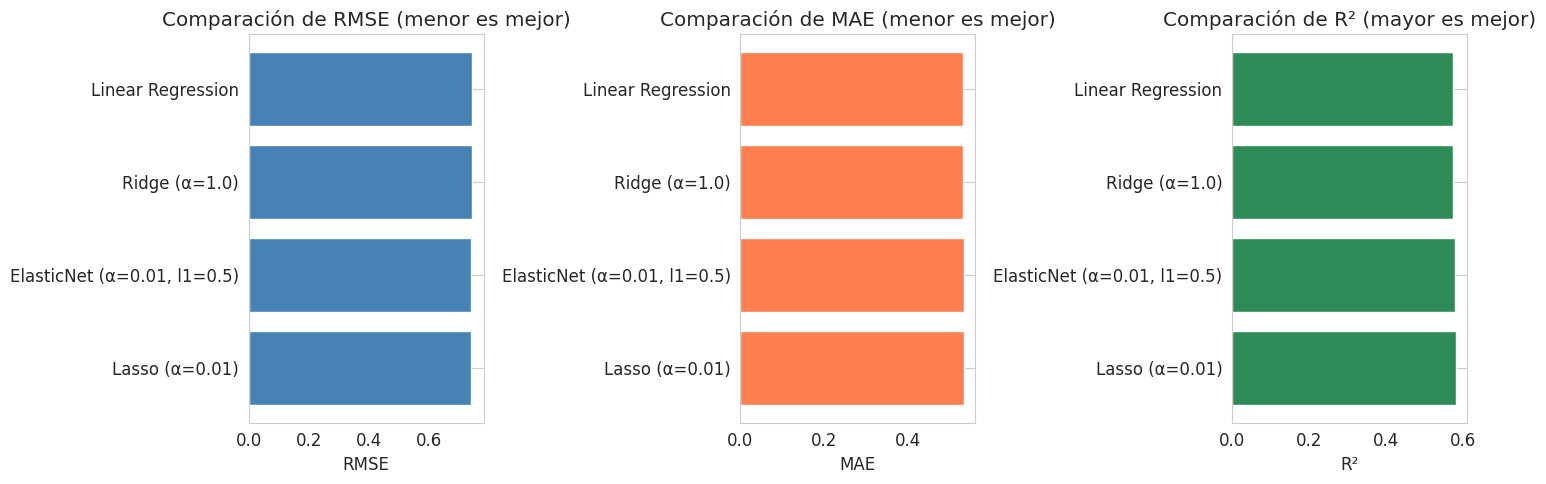

In [7]:
# Gráfico comparativo de métricas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# RMSE
axes[0].barh(results_df['Modelo'], results_df['Test RMSE'], color='steelblue')
axes[0].set_xlabel('RMSE')
axes[0].set_title('Comparación de RMSE (menor es mejor)')
axes[0].grid(axis='x')

# MAE
axes[1].barh(results_df['Modelo'], results_df['Test MAE'], color='coral')
axes[1].set_xlabel('MAE')
axes[1].set_title('Comparación de MAE (menor es mejor)')
axes[1].grid(axis='x')

# R²
axes[2].barh(results_df['Modelo'], results_df['Test R²'], color='seagreen')
axes[2].set_xlabel('R²')
axes[2].set_title('Comparación de R² (mayor es mejor)')
axes[2].grid(axis='x')

plt.tight_layout()
plt.show()

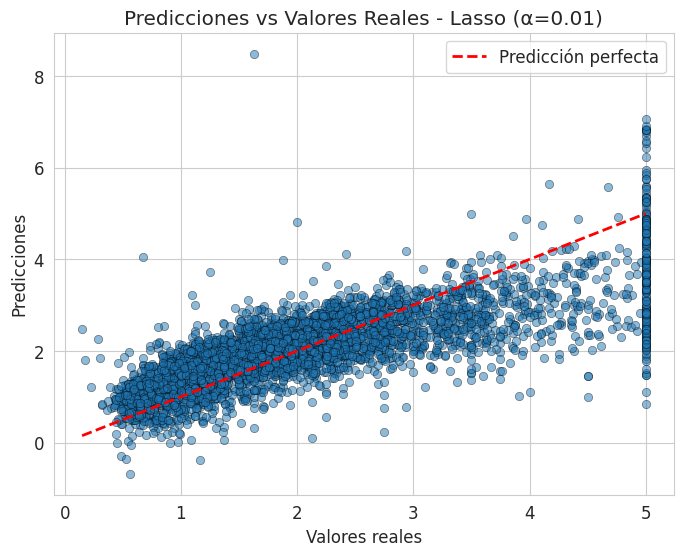

In [8]:
# Gráfico de predicciones vs valores reales (mejor modelo)
best_model_name = results_df.iloc[0]['Modelo']
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Predicción perfecta')
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title(f'Predicciones vs Valores Reales - {best_model_name}')
plt.legend()
plt.grid(True)
plt.show()

## 6. Análisis de Coeficientes (Interpretabilidad)

Visualizamos los coeficientes de cada modelo para entender qué características influyen más en el precio.

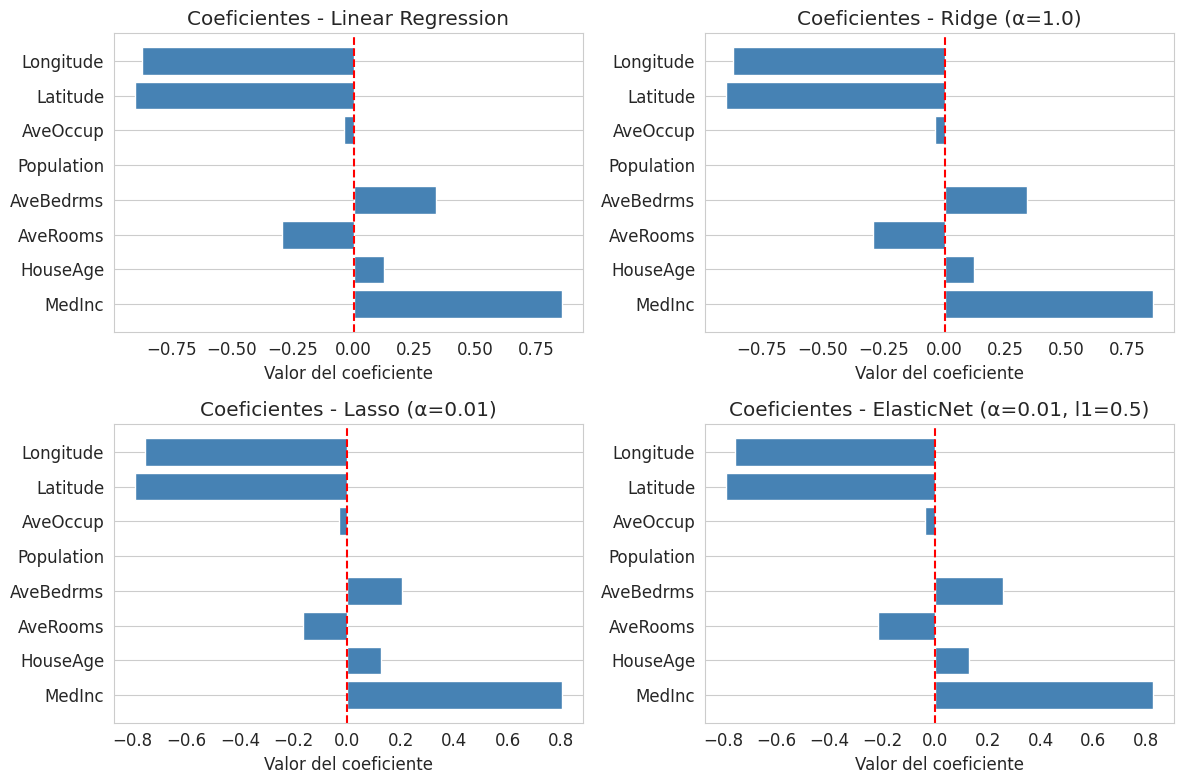


📊 TABLA DE COEFICIENTES POR MODELO


,Linear Regression,Ridge (α=1.0),Lasso (α=0.01),"ElasticNet (α=0.01, l1=0.5)"
MedInc,0.8544,0.8543,0.8010,0.8240
HouseAge,0.1225,0.1226,0.1271,0.1300
AveRooms,-0.2944,-0.2942,-0.1628,-0.2161
AveBedrms,0.3393,0.3390,0.2062,0.2563
Population,-0.0023,-0.0023,-0.0000,-0.0000
AveOccup,-0.0408,-0.0408,-0.0306,-0.0359
Latitude,-0.8969,-0.8962,-0.7901,-0.7884
Longitude,-0.8698,-0.8691,-0.7557,-0.7570


In [9]:
# Extraer coeficientes de cada modelo
feature_names = X.columns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for idx, (name, model) in enumerate(models.items()):
    if name == 'Linear Regression':
        coef = model.coef_
    elif name == 'Ridge (α=1.0)':
        coef = model.coef_
    elif name == 'Lasso (α=0.01)':
        coef = model.coef_
    else:
        coef = model.coef_

    axes[idx].barh(feature_names, coef, color='steelblue')
    axes[idx].axvline(x=0, color='red', linestyle='--')
    axes[idx].set_title(f'Coeficientes - {name}')
    axes[idx].set_xlabel('Valor del coeficiente')
    axes[idx].grid(axis='x')

plt.tight_layout()
plt.show()

# Mostrar tabla de coeficientes
print("\n" + "="*60)
print("📊 TABLA DE COEFICIENTES POR MODELO")
print("="*60)

coef_df = pd.DataFrame(index=feature_names)
for name, model in models.items():
    if name == 'Linear Regression':
        coef_df[name] = model.coef_
    elif name == 'Ridge (α=1.0)':
        coef_df[name] = model.coef_
    elif name == 'Lasso (α=0.01)':
        coef_df[name] = model.coef_
    else:
        coef_df[name] = model.coef_

display(coef_df.round(4))

## 7. Simulacion

In [10]:
print("\n" + "="*60)
print("🔮 SIMULACIÓN: PREDICCIÓN CON DATOS NUEVOS")
print("="*60)

# Datos de ejemplo (valores hardcodeados de un distrito típico)
# Orden: MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude
nuevo_distrito = np.array([[
    5.0,      # Ingreso medio ($50,000)
    30.0,     # Edad media de las casas (30 años)
    6.0,      # Promedio de habitaciones por hogar
    1.0,      # Promedio de dormitorios por hogar
    1000.0,   # Población del bloque
    3.0,      # Ocupación promedio (personas por hogar)
    34.0,     # Latitud
    -118.0    # Longitud
]])

# Escalar los datos nuevos (usar el mismo scaler de entrenamiento)
nuevo_distrito_scaled = scaler.transform(nuevo_distrito)

print("\n📋 Datos del nuevo distrito:")
print(f"   • Ingreso medio: ${nuevo_distrito[0][0] * 10000:.0f}")
print(f"   • Edad media viviendas: {nuevo_distrito[0][1]:.0f} años")
print(f"   • Habitaciones promedio: {nuevo_distrito[0][2]:.1f}")
print(f"   • Dormitorios promedio: {nuevo_distrito[0][3]:.1f}")
print(f"   • Población: {nuevo_distrito[0][4]:.0f}")
print(f"   • Ocupación promedio: {nuevo_distrito[0][5]:.1f} personas/hogar")
print(f"   • Ubicación: ({nuevo_distrito[0][6]}, {nuevo_distrito[0][7]})")

print("\n🔮 Predicciones de precio medio (en cientos de miles de dólares):")
print("-" * 50)

predicciones = {}
for name, model in models.items():
    prediccion = model.predict(nuevo_distrito_scaled)[0]
    predicciones[name] = prediccion
    print(f"   • {name:30s}: ${prediccion * 100000:.2f}")

# Encontrar el mejor modelo (menor Test RMSE)
best_model_name = results_df.iloc[0]['Modelo']
best_model = models[best_model_name]
prediccion_best = best_model.predict(nuevo_distrito_scaled)[0]

print("\n" + "="*60)
print(f"🏆 PREDICCIÓN RECOMENDADA (usando {best_model_name}):")
print(f"   💰 Precio estimado: ${prediccion_best * 100000:.2f}")
print("="*60)


🔮 SIMULACIÓN: PREDICCIÓN CON DATOS NUEVOS

📋 Datos del nuevo distrito:
   • Ingreso medio: $50000
   • Edad media viviendas: 30 años
   • Habitaciones promedio: 6.0
   • Dormitorios promedio: 1.0
   • Población: 1000
   • Ocupación promedio: 3.0 personas/hogar
   • Ubicación: (34.0, -118.0)

🔮 Predicciones de precio medio (en cientos de miles de dólares):
--------------------------------------------------
   • Linear Regression             : $244702.80
   • Ridge (α=1.0)                 : $244712.02
   • Lasso (α=0.01)                : $248394.12
   • ElasticNet (α=0.01, l1=0.5)   : $247166.16

🏆 PREDICCIÓN RECOMENDADA (usando Lasso (α=0.01)):
   💰 Precio estimado: $248394.12


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 8. Conclusiones

**Resumen de resultados:**

- **Linear Regression**: Modelo baseline sin regularización. Puede sufrir overfitting si hay multicolinealidad.
- **Ridge (L2)**: Reduce coeficientes pero no los elimina. Útil cuando todas las características son relevantes.
- **Lasso (L1)**: Puede eliminar coeficientes (hacerlos cero). Útil para selección de características.
- **ElasticNet**: Combina L1 y L2. Mejor cuando hay correlación entre características.

**Métrica más importante para negocio (RMSE):**
- El RMSE está en las mismas unidades que el target (cientos de miles de dólares).
- Un RMSE de 0.5 significa que el error típico es ~$50,000.

**¿Qué modelo ganó?**
El modelo con menor RMSE en prueba fue **{{best_model_name}}**.

**Próximos pasos:**
- Ajustar hiperparámetros (α, l1_ratio) con GridSearchCV
- Probar transformaciones polinómicas para capturar no linealidades
- Comparar con árboles de decisión (semana 6) y boosting (semana 7)

---
**Fin de la Semana 03**